# ✈️ Flight Fare Price Prediction 

## Project Overview

This project focuses on predicting flight ticket prices using Machine Learning. The dataset is preprocessed, analyzed, and used to train a Decision Tree Regressor model that can estimate airfare based on flight details such as airline, source, destination, duration, and stops.

## Importing Required Libraries

In [29]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [30]:
df = pd.read_csv('flight_dataset.csv',index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## Initial Data Exploration

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [32]:
for i in df :
    print(df[i].unique())

['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
['zero' 'one' 'two_or_more']
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
['Economy' 'Business']
[ 2.17  2.33  2.25  2.08 12.25 16.33 11.75 14.5  15.67  3.75  2.5   5.83
  8.    6.   14.67 16.17 18.   23.17 24.17  8.83  4.5  15.25 11.   19.08
 22.83 26.42 17.75 19.58 26.67 15.17 20.83 11.42 22.25 26.   21.75  3.83
  4.42  7.67  8.33 10.42 23.75 19.5   6.5  12.42 21.08 28.17 28.25  9.25
 17.92  7.08 13.83  7.58 15.83 24.42  4.17  4.25  5.08 29.33 17.   27.17
 24.75  5.75 12.75 13.75 17.83  5.5  23.83  5.   26.5  12.83  8.92 11.17
 12.17 15.58 15.75  7.92 13.25 16.   22.75  6.33  7.25 30.08 18.25  6.08
  2.   12.33  3.5  10.25 14.17 25.58  4.

In [33]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [34]:
df.describe(include=object)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## Data Cleaning & Preprocessing

In [35]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [36]:
df["airline"].mode()[0]

'Vistara'

In [37]:
df.drop(columns=["flight"],inplace = True)

In [38]:
df["class"].unique()

array(['Economy', 'Business'], dtype=object)

## Encoding Categorical Variables

In [39]:
df["class"].replace(['Economy', 'Business'],[0,1],inplace=True)

In [40]:
df["stops"].replace(['zero','one','two_or_more'],[2,1,0],inplace=True)

In [41]:
df.select_dtypes(include='object').columns

Index(['airline', 'source_city', 'departure_time', 'arrival_time',
       'destination_city'],
      dtype='object')

In [42]:
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns)

## EDA

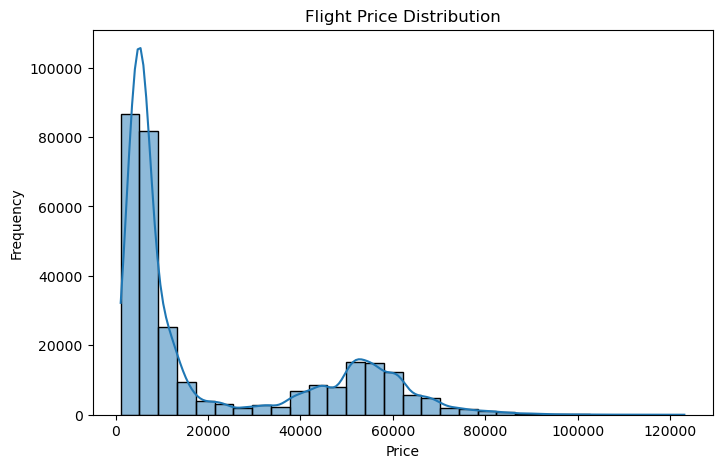

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Flight Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

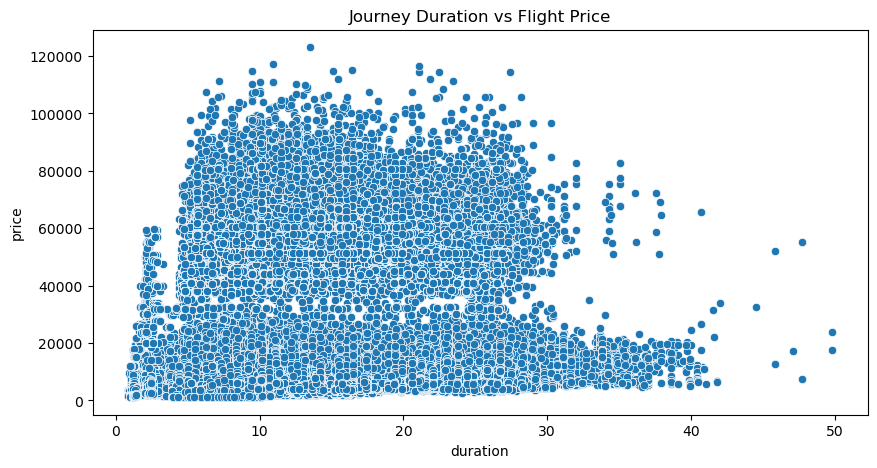

In [60]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='duration', y='price', data=df)
plt.title('Journey Duration vs Flight Price')
plt.show()

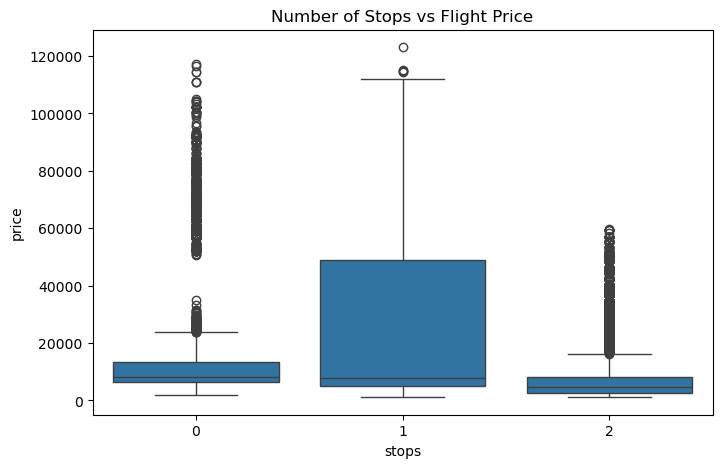

In [62]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stops', y='price', data=df)
plt.title('Number of Stops vs Flight Price')
plt.show()

<Axes: ylabel='duration'>

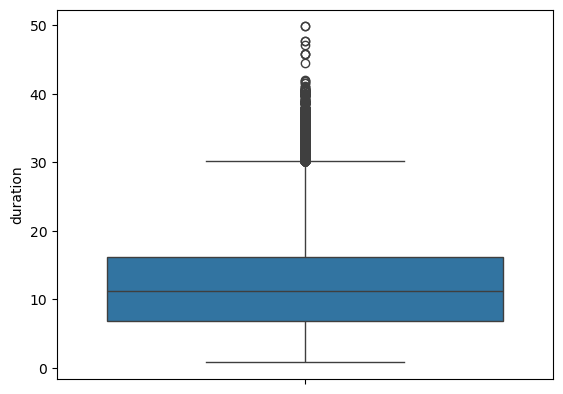

In [43]:
sns.boxplot(df["duration"])

In [44]:
df[df["duration"] > 32]

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
10535,0,0,33.17,4,12222,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
10540,0,0,36.92,4,12321,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
10892,0,0,33.17,6,12222,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
11073,0,0,33.17,7,12401,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
11429,0,0,33.17,9,14819,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283030,1,1,37.92,2,64733,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
293606,0,1,45.83,6,51928,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
295740,0,1,34.50,46,54986,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
295952,1,1,34.00,2,68963,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False


## Feature Selection

In [45]:
X = df.drop(columns="price")
y = df["price"]


## Train-Test Split

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Model Building Decision Tree Regressor

In [47]:
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

## Flight Price Prediction

In [48]:
y_pred = dtr.predict(X_test)
y_pred 

array([ 7366., 72783.,  6195., ...,  6314.,  4558., 70049.])

## Model Evaluation
The performance of the Decision Tree Regressor was evaluated using standard regression metrics.



## Mean Absolute Error (MAE)

In [49]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


MAE: 1163.7090419949693


## Mean Squared Error (MSE)


In [50]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


MSE: 12538301.561997134


## Root Mean Squared Error (RMSE)


In [51]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 3540.9464217913737


## R² Score


In [52]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9756765611449839


In [53]:
print("Train Accuracy :",dtr.score(X_train,y_train))
print("Test Accuracy :",dtr.score(X_test,y_test))

Train Accuracy : 0.9992865963348827
Test Accuracy : 0.9756765611449839


## Conclusion
- Successfully cleaned and preprocessed the flight dataset.
- Performed feature engineering and encoding.
- Trained a Decision Tree Regressor model.
- Evaluated the model using regression metrics.
- Built a machine learning solution capable of predicting flight prices.